<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/LiDAR_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install nuscenes-devkit open3d numpy matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from nuscenes.nuscenes import NuScenes

DATA_ROOT = "/content/drive/MyDrive/nuscenes"  # change if needed

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=DATA_ROOT,
    verbose=True
)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 8.027 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [4]:
rainy_scenes = []

for scene in nusc.scene:
    desc = scene["description"].lower()
    if "rain" in desc:
        rainy_scenes.append(scene)

print(f"Rainy scenes found: {len(rainy_scenes)}")
for s in rainy_scenes:
    print("-", s["name"], ":", s["description"])

Rainy scenes found: 1
- scene-1094 : Night, after rain, many peds, PMD, ped with bag, jaywalker, truck, scooter


In [5]:
scene = rainy_scenes[0]

sample_token = scene["first_sample_token"]
sample = nusc.get("sample", sample_token)

lidar_token = sample["data"]["LIDAR_TOP"]
lidar_sample = nusc.get("sample_data", lidar_token)

lidar_file = f"{DATA_ROOT}/{lidar_sample['filename']}" # Changed 'file_name' to 'filename'
print("LiDAR file:", lidar_file)

LiDAR file: /content/drive/MyDrive/nuscenes/samples/LIDAR_TOP/n015-2018-11-21-19-38-26+0800__LIDAR_TOP__1542800847948119.pcd.bin


In [6]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

pc = LidarPointCloud.from_file(lidar_file)
points = pc.points.T   # shape: (N, 4)

xyz = points[:, :3]
intensity = points[:, 3]

print("Points shape:", xyz.shape)

Points shape: (34400, 3)


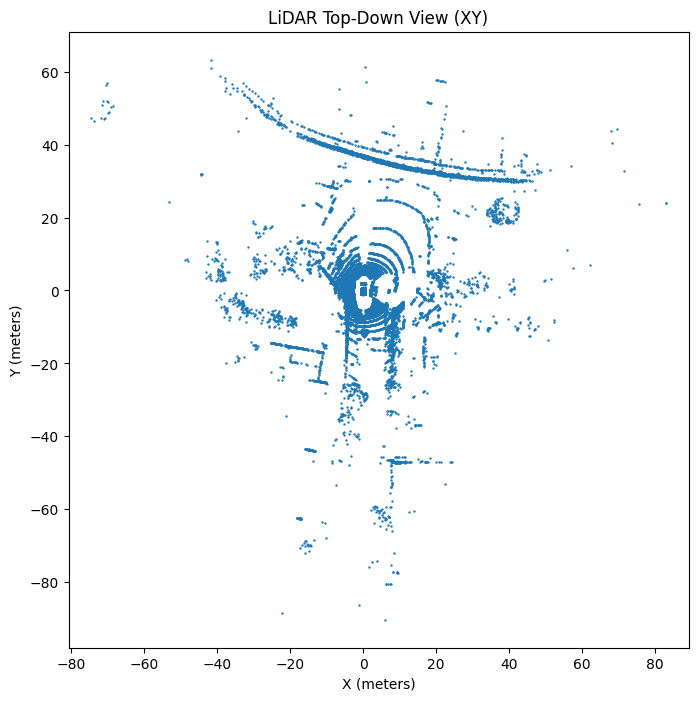

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Downsample for speed
idx = np.random.choice(len(xyz), size=20000, replace=False)
pts = xyz[idx]

plt.figure(figsize=(8, 8))
plt.scatter(pts[:, 0], pts[:, 1], s=0.5)
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.title("LiDAR Top-Down View (XY)")
plt.axis("equal")
plt.show()

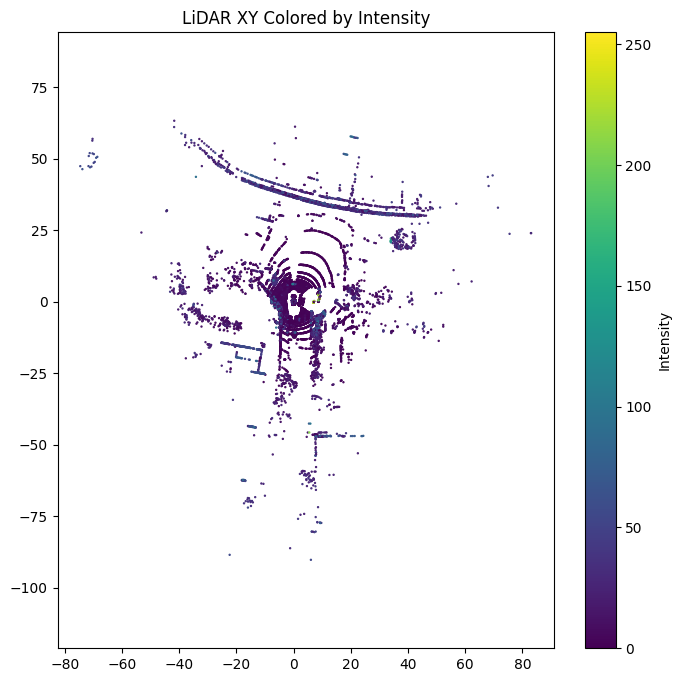

In [8]:
intensity_sub = intensity[idx]

plt.figure(figsize=(8, 8))
plt.scatter(
    pts[:, 0],
    pts[:, 1],
    c=intensity_sub,
    s=0.5,
    cmap="viridis"
)
plt.colorbar(label="Intensity")
plt.title("LiDAR XY Colored by Intensity")
plt.axis("equal")
plt.show()

In [9]:
clear_scenes = []

for scene in nusc.scene:
    desc = scene["description"].lower()
    if "rain" not in desc:
        clear_scenes.append(scene)

print("Clear scenes:", len(clear_scenes))
print("Example clear scene:", clear_scenes[0]["description"])

Clear scenes: 9
Example clear scene: Parked truck, construction, intersection, turn left, following a van


In [12]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

def load_lidar_from_scene(scene):
    sample_token = scene["first_sample_token"]
    sample = nusc.get("sample", sample_token)

    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    lidar_file = f"{DATA_ROOT}/{lidar_data['file_name']}"
    pc = LidarPointCloud.from_file(lidar_file)

    points = pc.points.T  # (N, 4)
    xyz = points[:, :3]
    intensity = points[:, 3]

    return xyz, intensity

In [13]:
from nuscenes.utils.data_classes import LidarPointCloud
import numpy as np

def load_lidar_from_scene(scene):
    sample_token = scene["first_sample_token"]
    sample = nusc.get("sample", sample_token)

    lidar_token = sample["data"]["LIDAR_TOP"]
    lidar_data = nusc.get("sample_data", lidar_token)

    # Fix: Changed 'file_name' to 'filename'
    lidar_file = f"{DATA_ROOT}/{lidar_data['filename']}"
    pc = LidarPointCloud.from_file(lidar_file)

    points = pc.points.T  # (N, 4)
    xyz = points[:, :3]
    intensity = points[:, 3]

    return xyz, intensity

xyz_clear, intensity_clear = load_lidar_from_scene(clear_scenes[0])
xyz_rain, intensity_rain = load_lidar_from_scene(rainy_scenes[0])

print("Clear points:", xyz_clear.shape[0])
print("Rainy points:", xyz_rain.shape[0])

Clear points: 34688
Rainy points: 34400


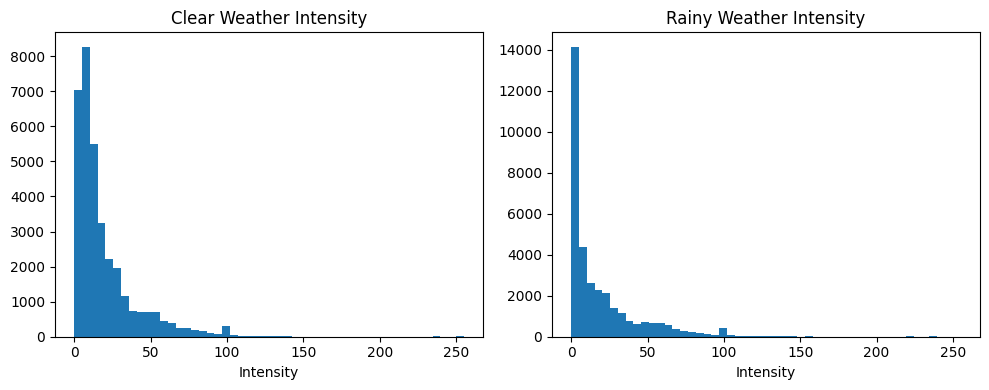

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(intensity_clear, bins=50)
plt.title("Clear Weather Intensity")
plt.xlabel("Intensity")

plt.subplot(1, 2, 2)
plt.hist(intensity_rain, bins=50)
plt.title("Rainy Weather Intensity")
plt.xlabel("Intensity")

plt.tight_layout()
plt.show()

In [15]:
def plot_xy(xyz, title):
    idx = np.random.choice(len(xyz), size=20000, replace=False)
    pts = xyz[idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(pts[:, 0], pts[:, 1], s=0.5)
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.title(title)
    plt.axis("equal")
    plt.show()

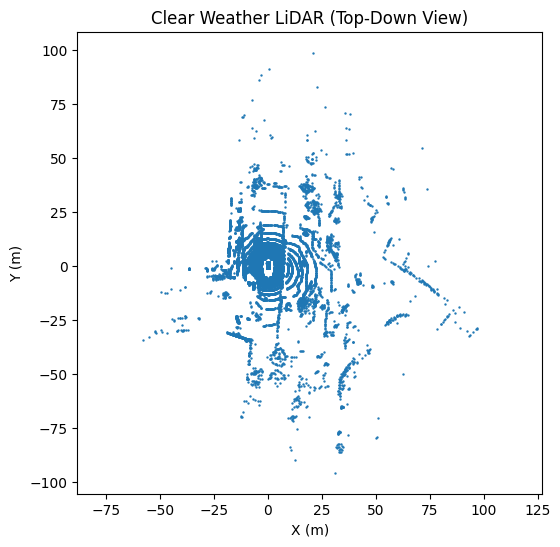

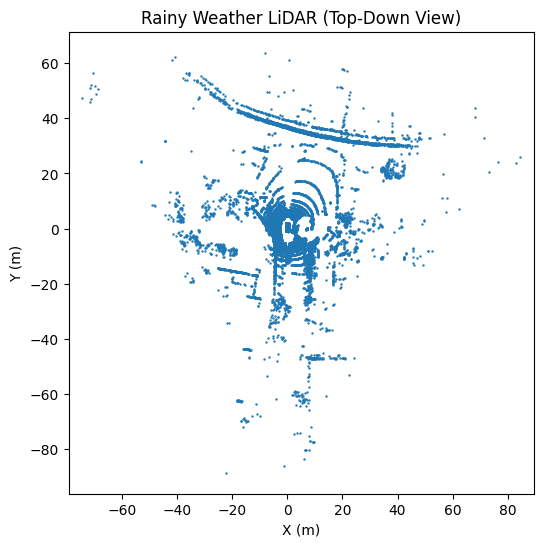

In [16]:
plot_xy(xyz_clear, "Clear Weather LiDAR (Top-Down View)")
plot_xy(xyz_rain, "Rainy Weather LiDAR (Top-Down View)")

In [17]:
def plot_xy_intensity(xyz, intensity, title):
    idx = np.random.choice(len(xyz), size=20000, replace=False)
    pts = xyz[idx]
    inten = intensity[idx]

    plt.figure(figsize=(6, 6))
    plt.scatter(
        pts[:, 0], pts[:, 1],
        c=inten, s=0.5, cmap="viridis"
    )
    plt.colorbar(label="Intensity")
    plt.title(title)
    plt.axis("equal")
    plt.show()

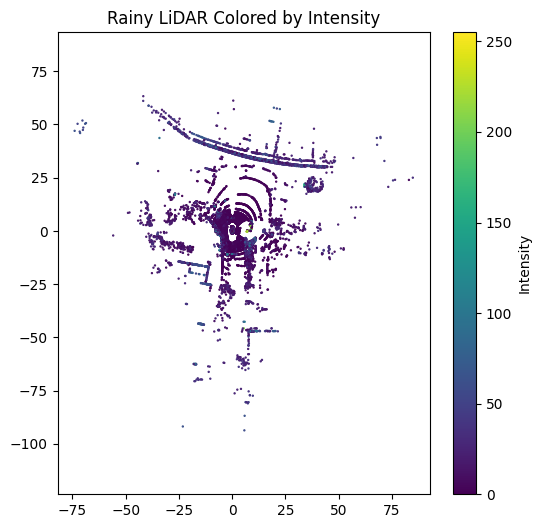

In [18]:
plot_xy_intensity(xyz_rain, intensity_rain, "Rainy LiDAR Colored by Intensity")